In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [2]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
cols_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos_penguins = datos_penguins.dropna(subset=cols_numericas + ['species'])

Vamos a hacer un pairplot! El pairplot agarra de a pares de variables, y las grafica.
En la diagonal principal, realiza KDEs de las variables individualmente

Basicamente es hacer el analisis bivariado completo en un solo bloque de codigo.

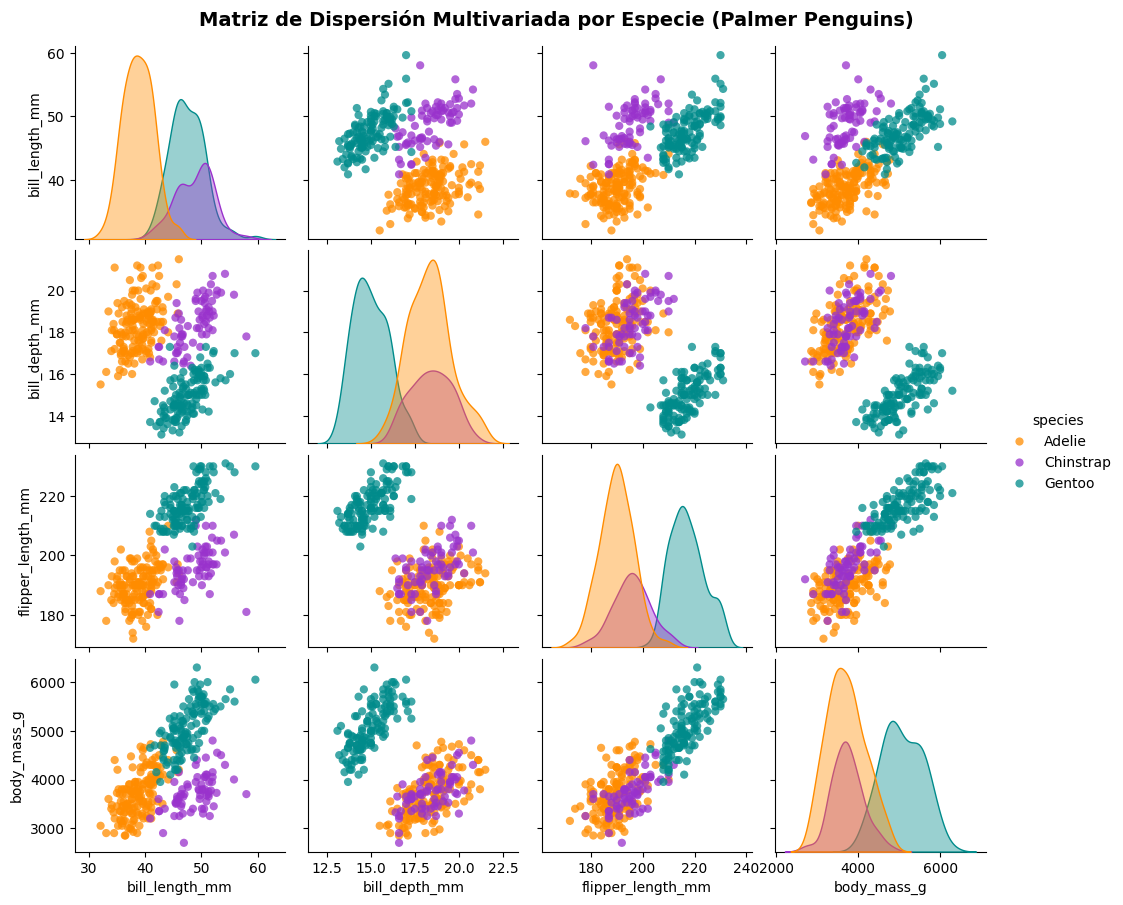

In [3]:
g = sns.pairplot(
    data=datos_penguins,
    vars=cols_numericas, # que solo cruce el cruce entre estas variables
    hue='species', # pinta cada especie diferente
    palette=paleta_penguins,
    diag_kind='kde',
    plot_kws={'alpha': 0.75, 's': 35, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.4},
    height=2.3,
    aspect=1.1
)

# Ajuste de títulos y márgenes
g.fig.subplots_adjust(top=0.94)
g.fig.suptitle("Matriz de Dispersión Multivariada por Especie (Palmer Penguins)", fontsize=14, weight='bold')

plt.show()

En el pairplot, podemos ver que la especie mas separable es la Gentoo, y se vislumbra que el bill_length es una variable que nos podria permitir separar la raza Chinstrap de la raza Adelie, ya que sus picos son un poco mas largos.

Ahora, veamos el grafico de coordenadas paralelas, con los datos normalizados

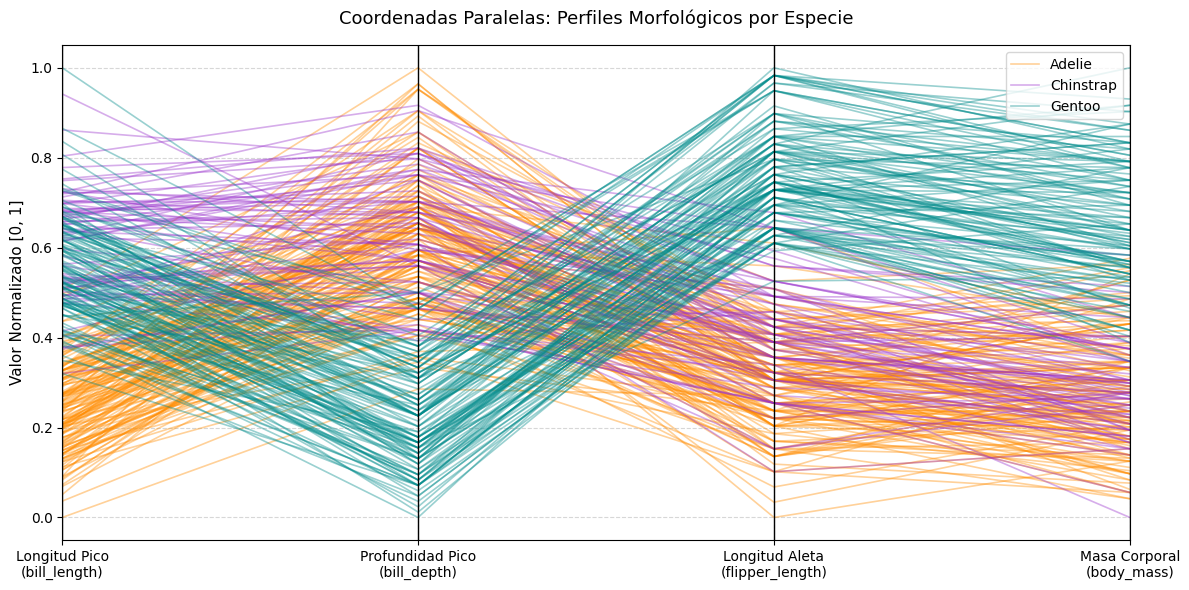

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

#columnas en orden
cols_morfologicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos_penguins = datos_penguins.dropna(subset=cols_morfologicas + ['species']).copy()

#Normalización Min-Max [0, 1]
scaler = MinMaxScaler()
df_norm = datos_penguins.copy()
df_norm[cols_morfologicas] = scaler.fit_transform(datos_penguins[cols_morfologicas]) #escalado

#gráfico asegurando el orden exacto de columnas
plt.figure(figsize=(12, 6))
paleta_colores = ['#FF8C00', '#9932CC', '#008B8B']  # Adelie, Chinstrap, Gentoo

parallel_coordinates(
    df_norm[['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']],
    class_column='species', #que pinte diferente a cada especie
    color=paleta_colores,
    alpha=0.4,
    linewidth=1.2
)

plt.title("Coordenadas Paralelas: Perfiles Morfológicos por Especie", fontsize=13, pad=15)
plt.ylabel("Valor Normalizado [0, 1]", fontsize=11)
plt.xticks(
    ticks=range(len(cols_morfologicas)),
    labels=['Longitud Pico\n(bill_length)', 'Profundidad Pico\n(bill_depth)', 'Longitud Aleta\n(flipper_length)', 'Masa Corporal\n(body_mass)'],
    fontsize=10
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Los gentoo tienen el patron mas identificable, ademas podemos ver claramente la caida que tienen en la profundidad del pico y despues suben hadcia el tope en aleta y peso... ese patron en "V" es como la "firma" de los Gentoo. Tambien para relacionarlo con lo que hice y dije antes, ese cruce de lineas verdes subiendo mientras las otras bajan explica lo de las correlaciones espurias globales...

- La firma de los Adelie es el camino casi opuesto a los Gentoo en su cabeza, arrancan lo mas abajo posible del largo del pico, suben a la parte superior en profundidad y luego caen a la parte baja de la aleta y peso.

- Con respecto a los Chinstrap... este grafico muestra por que se mezclaban en los scatter plots, tienen un perfil bastante hibrido. Comparten el inicio de los Gentoo pero luego no caen, se mantienen altos en profundidad del pico y se mezclan con los Adelie y a partir de ahi comparten la misma ruta que estos.

Ahora, pasamos a ver los Heatmaps de correlacion segmentados por especie.


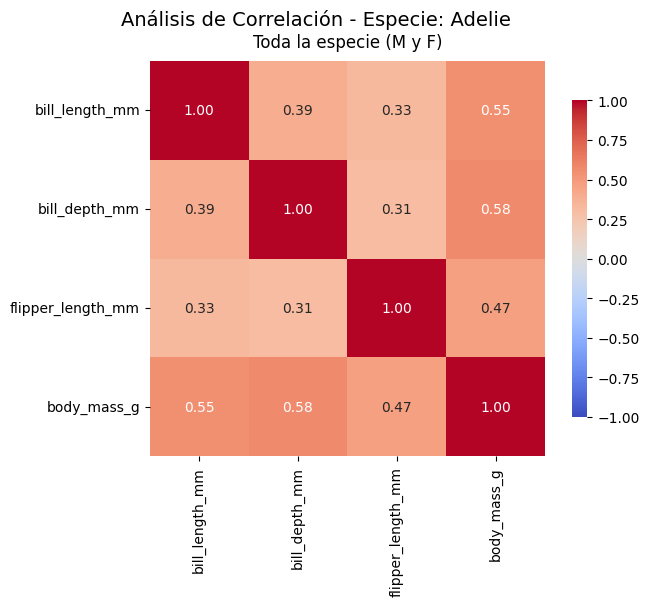

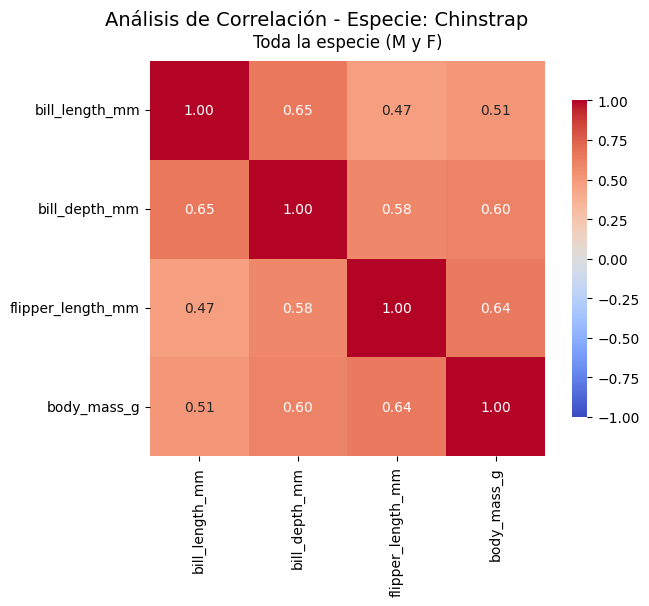

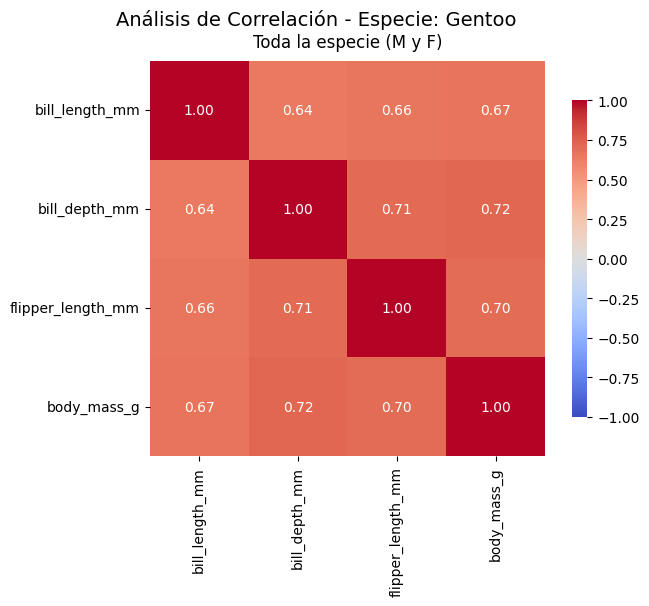

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se obtienen las especies únicas del dataset
especies = datos_penguins['species'].dropna().unique()

for especie in especies:
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.suptitle(f"Análisis de Correlación - Especie: {especie}", fontsize=14, y=0.98)
    
    #Filtrado y cálculo de correlación
    df_especie = datos_penguins[datos_penguins['species'] == especie]
    num_especie = df_especie.select_dtypes(include=[np.number])
    matriz_total = num_especie.corr()
    
    #generación del Heatmap en el eje único
    sns.heatmap(
        matriz_total, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        vmin=-1, vmax=1, 
        square=True,
        cbar_kws={'shrink': 0.8},
        ax=ax
    )
    ax.set_title("Toda la especie (M y F)", pad=10)
    
    plt.tight_layout()
    plt.show()

Confirmamos todo lo anterior... podemos ver que no hay ningun color azul! Confirmamos la teoria de que "Pinguino mas grande -> pico mas grande" por especie.
**todas las variables físicas tienen una correlación estrictamente positiva** ,Las correlaciones espurias negativas descubiertas se invirtieron.

### Pasemos al dendograma

MATRIZ DE DISTANCIA


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,0.000,0.765,0.344,0.405
bill_depth_mm,0.765,0.000,0.416,0.528
flipper_length_mm,0.344,0.416,0.000,0.129
body_mass_g,0.405,0.528,0.129,0.000


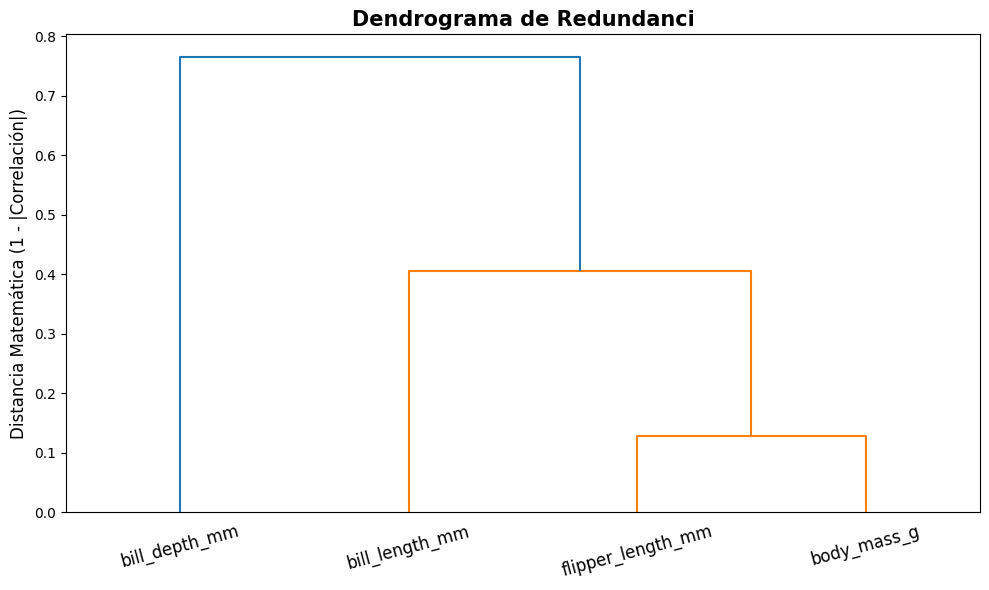

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

matriz_correlacion = datos_penguins.select_dtypes(include=[np.number]).corr()

#transofrmamos esta correlacion en distancia
matriz_distancia=1-np.abs(matriz_correlacion)
#forzamos la diagonal a ser 0, si no quedaba 0,00000000000000
np.fill_diagonal(matriz_distancia.values,0)

#mostramos la matriz de distancias
print("MATRIZ DE DISTANCIA")
display(matriz_distancia.round(3))

#me daba error y ni idea por que era, es como que scipy pedia un vector , asi que se "condensan" los datos en un vector
distancia_condensada=squareform(matriz_distancia)

#agrupamiento,'complete' calcula la distancia maxima entre cluster para unir
agrupamiento=linkage(distancia_condensada,method='complete')

#dibujamos el dendograma
plt.figure(figsize=(10, 6))
dendrogram(
    agrupamiento,
    labels=matriz_correlacion.columns, # Usamos los nombres 
    leaf_rotation=15,           
    leaf_font_size=12,
    color_threshold=0.5    #colorea las ramas para resaltar los grupos muy unidos
)

plt.title("Dendrograma de Redundanci", fontsize=15, fontweight='bold')
plt.ylabel("Distancia Matemática (1 - |Correlación|)", fontsize=12)
plt.tight_layout()
plt.show()

Analisis del dendograma

Sirve para descubrir las redundancias morfologicas, un valor cercano a 0 en la matriz de distancia, indica que las variables "miden" lo mismo.
- La distancia entre el largo de la aleta y la masa corporal es la mas baja de todas (0,127), el dendograma lo refleja enj el primer puente o escalon, y la altura desde el eje X hacia el escalon es de justamente 0,127. La conclusion de este resultado es que el largo de la aleta y el peso son variables redundantes, ambas miden el tamaño general del pinguino.
- el largo del pico seria como la variable interna, se une al cluster principal un poco mas arriba , a una altura de (0,411). Esto indica que el largo del pico tiene cierta relacion con el tamaño general del ave, pero aporta informacion propia como para no considerarlo redundante al peso o a la aleta.
- La variable mas independiente de todas es la profundidad del pico, su distancia al eje X es de 0,77, la conclusion de esto es que el grosor del pico es la caracteristica morfologica mas independiente, no esta atada al tamaño general del pinguino (lo comprobamos sabiendo que el gentoo son los pinguinos mas grandes pero tienen los picos mas finos)

En caso de tener problemas de dimensionalidad, este dendograma nos ayudaria a simplificar el analisis para descartar variables, ya que tranquilamente podriamos eliminar o el largo de la aleta o la masa corporal.

### Hagamos el spider plot

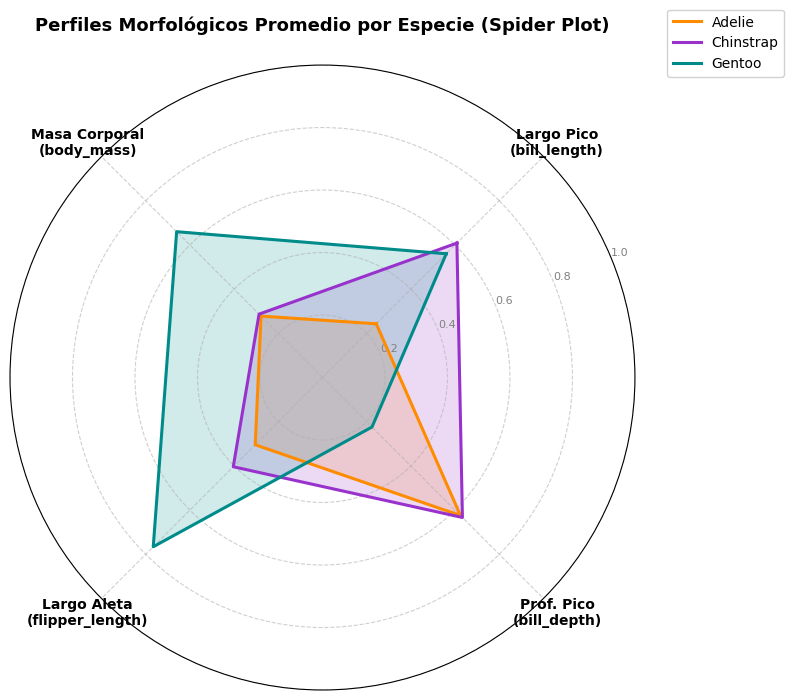

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

#filtrado y normalización global [0, 1]
cols_morfologicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos_penguins = datos_penguins.dropna(subset=cols_morfologicas + ['species']).copy()

scaler = MinMaxScaler()
df_norm = datos_penguins.copy()
df_norm[cols_morfologicas] = scaler.fit_transform(datos_penguins[cols_morfologicas])

#cálculo del promedio normalizado por especie
promedios = df_norm.groupby('species')[cols_morfologicas].mean()

# Configuración de geometría polar
etiquetas = [
    'Largo Pico\n(bill_length)',
    'Prof. Pico\n(bill_depth)',
    'Largo Aleta\n(flipper_length)',
    'Masa Corporal\n(body_mass)'
]
num_vars = len(cols_morfologicas)

# Ángulos equiespaciados para cada eje (en radianes)
angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# Cerrar el lazo conectando el último punto con el primero
angulos += angulos[:1]

# Construcción
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar')) #prepara el dibujo ciruclar
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

for especie, color in paleta_penguins.items(): #da una vuelta por especie
    valores = promedios.loc[especie].tolist()
    valores += valores[:1]  # Cerrar el polígono repitiendo el primer valor
    
    ax.plot(angulos, valores, label=especie, color=color, linewidth=2.2)
    ax.fill(angulos, valores, color=color, alpha=0.18)

# ajustes de formato y grilla
ax.set_theta_offset(np.pi / 4)           # Rotar para alinear estéticamente los 4 ejes
ax.set_theta_direction(-1)               # Sentido horario
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas, fontsize=10, weight='semibold')

ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='gray')
ax.grid(True, linestyle='--', alpha=0.6)

plt.title("Perfiles Morfológicos Promedio por Especie (Spider Plot)", fontsize=13, weight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), framealpha=0.9)
plt.tight_layout()
plt.show()

El grafico nos permite visualizar las medidas morfologicas de cada especie como un "perfil estadistico", y nos ayuda a facilitar la comparacion de las proporciones de cada medida

Aca se ve bien claro la diferencia! Los pinguinos chinstrap tienen picos mas largos, y aletas un poco mas largas que las de los Adelie!

## CONCLUSION EJERCICIO 3

El analisis multivariado me ayudo a identificar que el datset presenta una fuerte redundancia interna  que puede llevar a conclusiones erroneas si no se estratifica. 
- Teniamos correlaciones espurias (paradoja de simpson, esta en la teoria y lo busque por las dudas), ya que habia correlaciones negativas falsas y al segmentar por especie nos dimos cuentas que estas correlaciones eran todas positivas dentro de cada familia de pinguinos, entonces concluimos que el aumento de cualquier medida fisica acompaña proprocionalmente el aumento de las demas.

- Tambien detectamos una redundancia que lo comprobamos gracias al dendograma, ya que el largo de la aleta y la masa corporal estaban muy correlacionadas, se puede decir que se pueden unir en una sola variable que podriamos llamar "tamaño corporal"

- Con las coordenadas paralelas y el spider plot identificamos el "perfil" o "firma" de cada especie, revelando que niguna es una version mas chiquita o mas grande que la otra.

- Sigo pensando que el cruce bivariado entre el largo del pico y la profundidad del mismo es el patron mas discriminante del conjunto de datos, divide a cada especie en tres cluster con muy poco solapamiento.